In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# Who are our top 10 highest-value customers by total sales, and are their accounts highly profitable?

In [5]:
#top10, customers, sales, profitability

In [6]:
sales_profit_by_customer = df.groupby('Customer ID')[['Sales','Profit']].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum')
).round(2)
sales_profit_by_customer

,total_sales,total_profit
Customer ID,,
AA-10315,13747.42,447.71
AA-10375,5884.20,677.48
AA-10480,17717.52,1526.56
AA-10645,15343.89,3051.44
AA-315,2243.26,535.56
...,...,...
YS-21880,18703.61,3091.60
ZC-11910,7.17,-15.57
ZC-21910,28472.81,452.51


In [8]:
sales_profit_custid = sales_profit_by_customer.sort_values(by='total_sales', ascending=False).head(10)

In [12]:
sales_profit_custid.reset_index(inplace=True)

In [17]:
sales_profit_custid

,Customer ID,total_sales,total_profit
0,TA-21385,35668.12,6275.02
1,GT-14710,34471.89,5164.83
2,TC-20980,34218.27,8787.47
3,BW-11110,31183.18,3344.56
4,SM-20320,31125.30,-1083.67
5,HL-15040,29664.23,7657.51
6,SE-20110,29532.63,5863.61
7,PS-19045,29252.32,4426.20
8,RB-19360,29197.63,8523.94
9,ZC-21910,28472.81,452.51


In [11]:
customers = df[['Customer ID','Customer Name']]

In [22]:
sales_profit_tencustomers = pd.merge(sales_profit_custid,customers, how='left', on='Customer ID').drop_duplicates()

In [23]:
sales_profit_tencustomers

,Customer ID,total_sales,total_profit,Customer Name
0,TA-21385,35668.12,6275.02,Tom Ashbrook
10,TA-21385,35668.12,6275.02,Unknown
48,TA-21385,35668.12,6275.02,NaN
65,GT-14710,34471.89,5164.83,Greg Tran
99,GT-14710,34471.89,5164.83,Unknown
112,GT-14710,34471.89,5164.83,NaN
139,TC-20980,34218.27,8787.47,Tamara Chand
141,TC-20980,34218.27,8787.47,Unknown
198,BW-11110,31183.18,3344.56,Bart Watters
280,SM-20320,31125.30,-1083.67,Sean Miller


In [35]:
sales_profit_tencustomers = sales_profit_tencustomers[(sales_profit_tencustomers['Customer Name'] != 'Unknown') | (sales_profit_tencustomers['Customer Name'] == pd.NA)]
sales_profit_tencustomers

,Customer ID,total_sales,total_profit,Customer Name
0,TA-21385,35668.12,6275.02,Tom Ashbrook
48,TA-21385,35668.12,6275.02,NaN
65,GT-14710,34471.89,5164.83,Greg Tran
112,GT-14710,34471.89,5164.83,NaN
139,TC-20980,34218.27,8787.47,Tamara Chand
198,BW-11110,31183.18,3344.56,Bart Watters
280,SM-20320,31125.30,-1083.67,Sean Miller
319,HL-15040,29664.23,7657.51,Hunter Lopez
366,SE-20110,29532.63,5863.61,Sanjit Engle
441,PS-19045,29252.32,4426.20,Penelope Sewall


In [43]:
sales_profit_tencustomers = sales_profit_tencustomers[~sales_profit_tencustomers['Customer Name'].isna()]
sales_profit_tencustomers.sort_values(by='total_sales', ascending=False)

,Customer ID,total_sales,total_profit,Customer Name
0,TA-21385,35668.12,6275.02,Tom Ashbrook
65,GT-14710,34471.89,5164.83,Greg Tran
139,TC-20980,34218.27,8787.47,Tamara Chand
198,BW-11110,31183.18,3344.56,Bart Watters
280,SM-20320,31125.30,-1083.67,Sean Miller
319,HL-15040,29664.23,7657.51,Hunter Lopez
366,SE-20110,29532.63,5863.61,Sanjit Engle
441,PS-19045,29252.32,4426.20,Penelope Sewall
513,RB-19360,29197.63,8523.94,Raymond Buch
578,ZC-21910,28472.81,452.51,Zuschuss Carroll


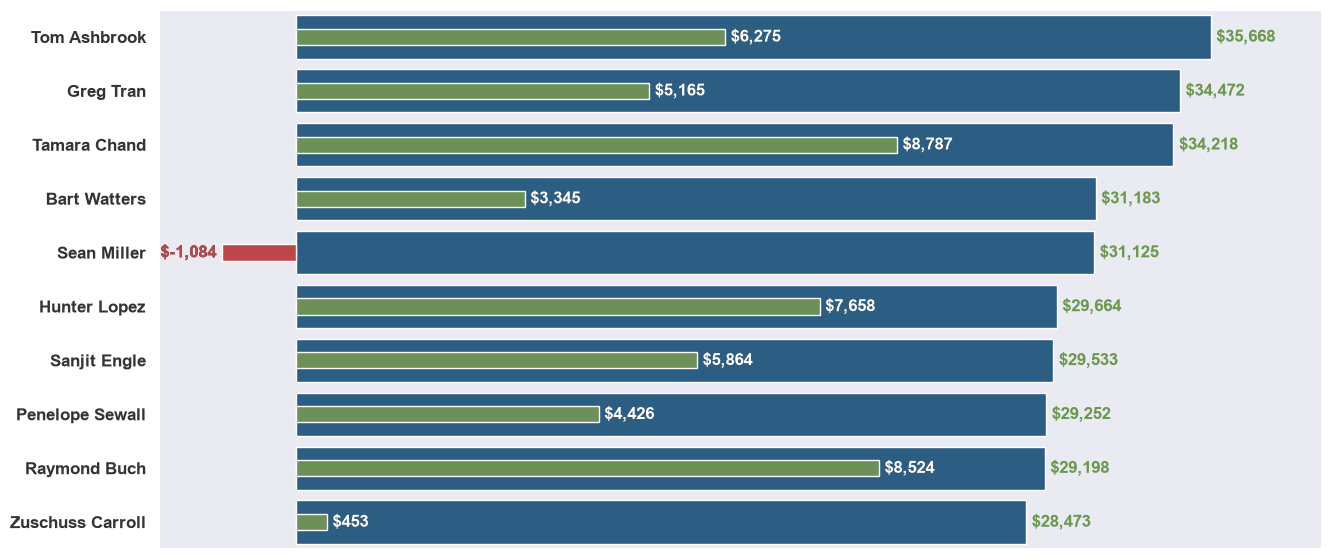

In [127]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(15,7), sharey=True)

ax = sns.barplot(
    data=sales_profit_tencustomers,
    x='total_sales',
    y='Customer Name',
    ax=ax,
    color='#1e6091'
)
# ================ ax x-axis ================
ax.set_xlim(-2000,40000) # set the min and max bin values
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_xticks([])
ax.tick_params(bottom=False)
ax.grid(False)

# ================ ax y-axis ================
ax.set_ylabel('')
ax.tick_params(axis='y' , labelsize=12, labelcolor='#333533')
plt.setp(ax.get_yticklabels(), fontweight='bold')

ax1 = ax.twiny()
ax1 = sns.barplot(
    data=sales_profit_tencustomers,
    x='total_profit',
    y='Customer Name',
    ax=ax1,
    color='#6a994e',
    width=0.3
)
# ================ ax1 x-axis ================
ax1.set_xlim(-2000,15000) # set the min and max bin values
ax1.set_xlabel('')
ax1.set_xticklabels([])
ax1.set_xticks([])
ax1.tick_params(top=False)
ax1.grid(False)

# ================ recolor bars with negative total_profit ================
for container in ax1.containers:
    for patch in container.patches:
        if patch.get_width() < 0:
            patch.set_facecolor('#bc4749')

# ================ display values of each bars ================
for container, container1 in zip(ax.containers, ax1.containers):
    ax.bar_label(container, fmt='${:,.0f}', fontsize=12, padding=4, fontweight='bold', color='#6a994e')
    ax1.bar_label(container1, fmt='${:,.0f}', fontsize=12, padding=4, fontweight='bold')

    labels1 = ax1.bar_label(container1, fmt='${:,.0f}', fontsize=12, padding=4, fontweight='bold')
    for label, patch in zip(labels1, container1.patches):
        if patch.get_width() < 0:
            label.set_color('#bc4749')
        else:
            label.set_color('white')
            
def sync_zero(ax, ax1):
    x0min, x0max = ax.get_xlim()
    x1min, x1max = ax1.get_xlim()

    # fraction of each axis that lies left of zero
    f0 = -x0min / (x0max - x0min)
    f1 = -x1min / (x1max - x1min)

    # use whichever fraction is larger so neither axis gets clipped
    f = max(f0, f1)

    # keep each axis's positive max fixed, stretch/shrink the negative side to match f
    def rescale(xmax, f):
        new_min = -f * xmax / (1 - f)
        return new_min, xmax

    new_x0min, new_x0max = rescale(x0max, f)
    new_x1min, new_x1max = rescale(x1max, f)

    ax.set_xlim(new_x0min, new_x0max)
    ax1.set_xlim(new_x1min, new_x1max)
sync_zero(ax, ax1)



In [130]:
# Business Question 9:
# Who are our top 10 highest-value customers by total sales, and are their accounts highly profitable?

# Answer:
# Tom Ashbrook tops the sales with amazing amount of $35k and Zuschuss Caroll gets the lowest sales and profit among the rest.
# Tamara Chand and Raymond Buch is almost tied when it comes to profit around $8,5k whilst Sean Miller results in negative profit despite getting the
# 5th place in sales.